In [1]:
import nilmtk

In [2]:
from nilmtk import DataSet
from nilmtk.utils import print_dict


In [3]:
iawe = DataSet('/home/jasil/Downloads/iawe.h5')


In [4]:
print_dict(iawe.metadata)

In [5]:
print(iawe.buildings)

OrderedDict([(1, Building(instance=1, dataset='iAWE'))])


In [6]:
building = iawe.buildings[1]

In [7]:
elec = building.elec
elec

MeterGroup(meters=
  ElecMeter(instance=1, building=1, dataset='iAWE', site_meter, appliances=[])
  ElecMeter(instance=2, building=1, dataset='iAWE', site_meter, appliances=[])
  ElecMeter(instance=3, building=1, dataset='iAWE', appliances=[Appliance(type='fridge', instance=1)])
  ElecMeter(instance=4, building=1, dataset='iAWE', appliances=[Appliance(type='air conditioner', instance=1)])
  ElecMeter(instance=5, building=1, dataset='iAWE', appliances=[Appliance(type='air conditioner', instance=2)])
  ElecMeter(instance=6, building=1, dataset='iAWE', appliances=[Appliance(type='washing machine', instance=1)])
  ElecMeter(instance=7, building=1, dataset='iAWE', appliances=[Appliance(type='computer', instance=1)])
  ElecMeter(instance=8, building=1, dataset='iAWE', appliances=[Appliance(type='clothes iron', instance=1)])
  ElecMeter(instance=9, building=1, dataset='iAWE', appliances=[Appliance(type='unknown', instance=1)])
  ElecMeter(instance=10, building=1, dataset='iAWE', appliances=[A

In [8]:
mains = building.elec.mains()

In [21]:
ac = building.elec['air conditioner']

In [22]:
ac

ElecMeter(instance=4, building=1, dataset='iAWE', appliances=[Appliance(type='air conditioner', instance=1)])

In [23]:
ac_power = ac.power_series(sample_period=60)


In [24]:
import pandas as pd

ac_power = pd.concat(
    ac.power_series(sample_period=60)
)

ac_power.head()



2013-06-07 20:34:00+05:30    1142.919556
2013-06-07 20:35:00+05:30     371.239563
2013-06-07 20:36:00+05:30     367.887329
2013-06-07 20:37:00+05:30     702.714050
2013-06-07 20:38:00+05:30    1655.944458
Freq: 60S, Name: (power, active), dtype: float32

In [25]:
mains_power = pd.concat(
    mains.power_series(sample_period=60)
)

mains_power.head()


AttributeError: 'DataFrame' object has no attribute 'power_series'

In [14]:
fridge_power.to_csv("iawe_fridge_raw.csv")
mains_power.to_csv("iawe_mains_raw.csv")


In [15]:
import pandas as pd

# Load CSVs
mains = pd.read_csv(
    "iawe_mains_raw.csv",
    index_col=0,
    parse_dates=True
)

fridge = pd.read_csv(
    "iawe_fridge_raw.csv",
    index_col=0,
    parse_dates=True
)

# Rename column (CSV has unnamed column)
mains.columns = ['mains']
fridge.columns = ['fridge']

# Align by timestamp
data = pd.concat([mains, fridge], axis=1)

# Keep only common timestamps
data = data.dropna()

data.head()


,mains,fridge
2013-06-07 05:30:00+05:30,325.20004,0.15758333
2013-06-07 05:31:00+05:30,317.23148,0.16056666
2013-06-07 05:32:00+05:30,350.84314,0.15817021
2013-06-07 05:33:00+05:30,449.42746,105.3328
2013-06-07 05:34:00+05:30,443.80338,120.26506


In [16]:


fraction = elec.submeters().fraction_per_meter().dropna()



10/10 ElecMeter(instance=12, building=1, dataset='iAWE', appliances=[Appliance(type='motor', instance=1)])ce=1)]))

In [18]:
import matplotlib.pyplot as plt

(<networkx.classes.digraph.DiGraph at 0x75e144ba4b50>, <Axes: >)

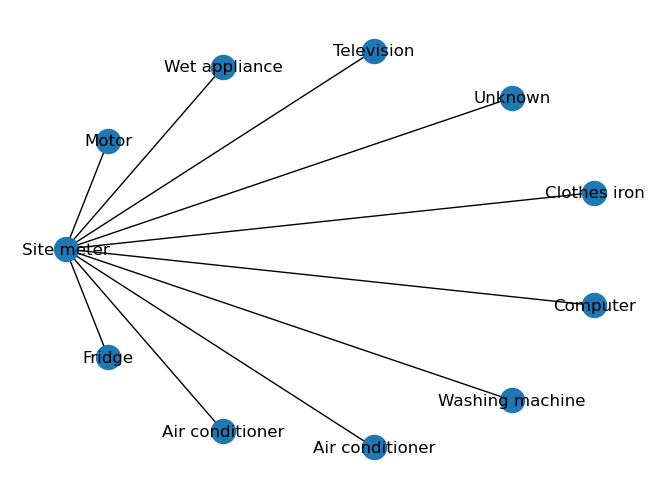

In [19]:
elec.draw_wiring_graph()

In [ ]:


from pandas.plotting import autocorrelation_plot

elec.mains().plot_autocorrelation();

Loading data for meter ElecMeterID(instance=2, building=1, dataset='iAWE')     
Done loading data all meters for this chunk.


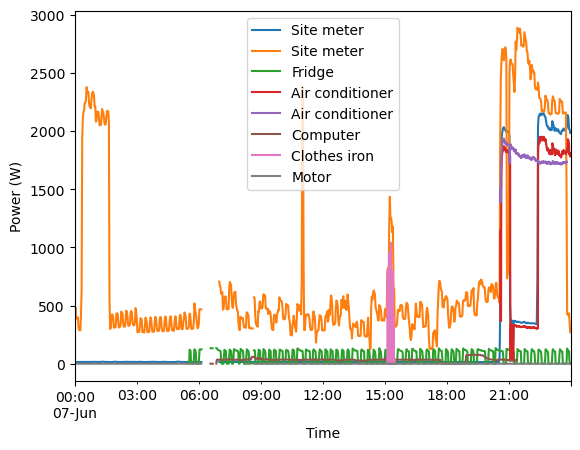

In [20]:
iawe.set_window(start='2013-06-07', end='2013-06-08')
elec.plot();
plt.xlabel("Time");